In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import random

# Task 1

c:\NTHU\深度學習\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\NTHU\深度學習\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38917 (\N{CJK UNIFIED IDEOGRAPH-9805}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


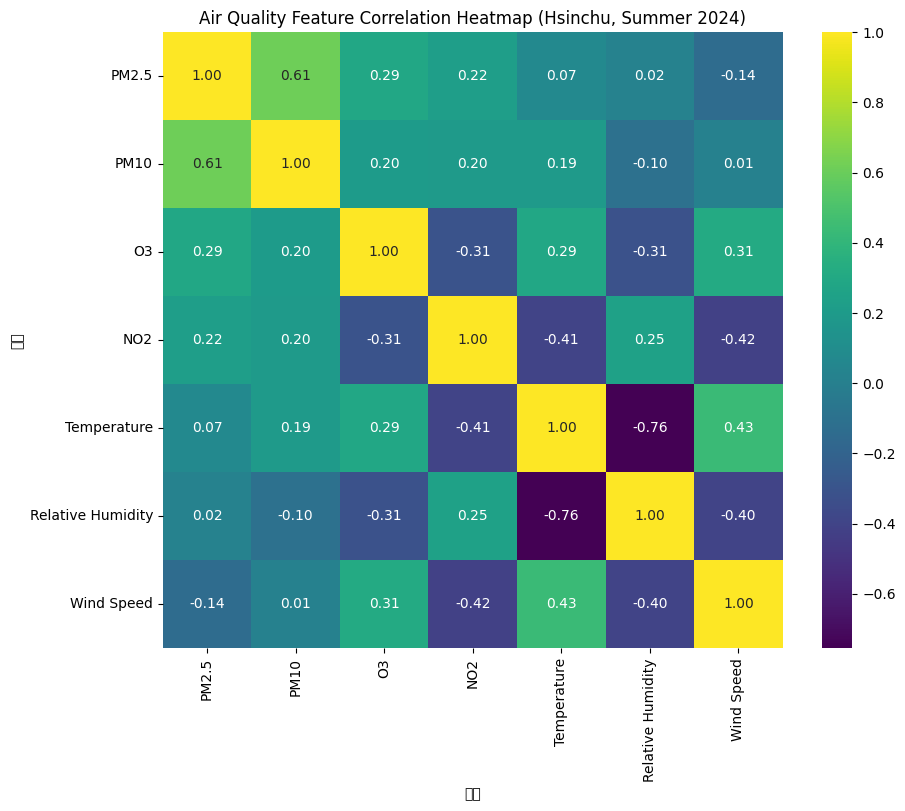

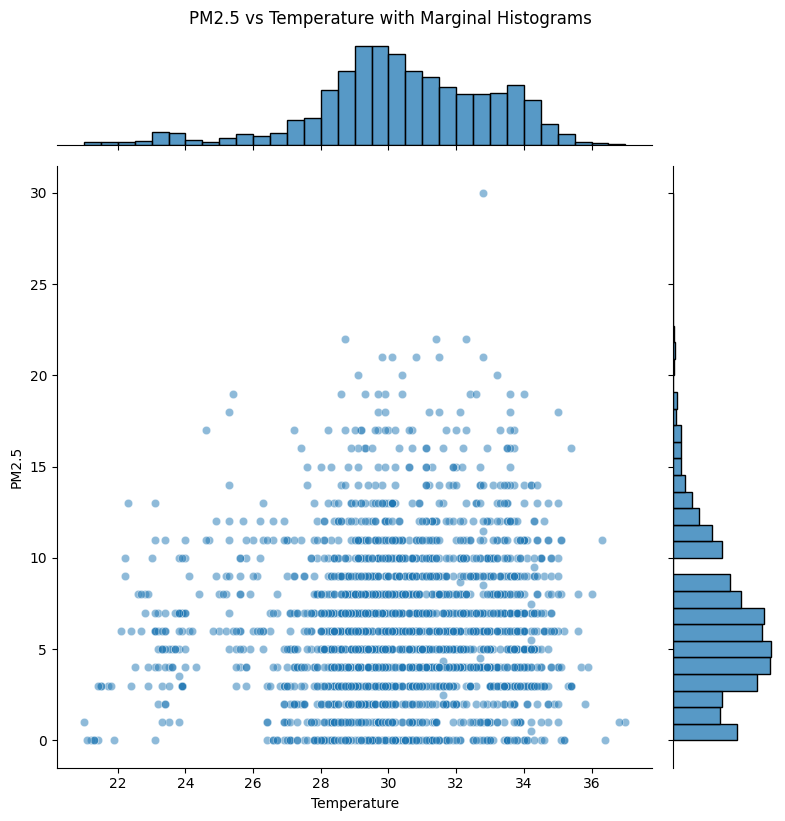

In [11]:
# 1. 讀取檔案
df = pd.read_csv('新竹_2024.csv')

# 2. 資料前處理 (Data Preprocessing)

# 定義 00~23 的小時欄位名稱
hour_columns = [f"{i:02d}" for i in range(24)]

# 轉換格式: 只 melt 我們確定是小時的那些欄位
df_melted = df.melt(id_vars=['測站', '日期', '測項'], value_vars=hour_columns, var_name='Hour', value_name='Value')

# 處理時間: 將 '日期' 和 'Hour' 合併成 datetime 格式
# 注意: 原始日期格式為 YYYY/MM/DD，我們先統一轉成 datetime object
df_melted['Date'] = pd.to_datetime(df_melted['日期']).dt.date
df_melted['Timestamp'] = pd.to_datetime(df_melted['Date'].astype(str) + ' ' + df_melted['Hour'] + ':00:00')

# 轉成數值: 將 'Value' 轉為數字，無法轉的變 NaN (例如 'NR')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

# 重塑資料 (Pivot): 讓每個測項變成一個欄位
df_pivot = df_melted.pivot(index='Timestamp', columns='測項', values='Value')

# 3. 篩選資料 (Filtering)
# 選取 2024 年夏季 (6月-8月)
df_summer = df_pivot.loc['2024-06-01':'2024-08-31'].copy()

# 選取需要的特徵並重新命名
target_features = {
    'PM2.5': 'PM2.5',
    'PM10': 'PM10',
    'O3': 'O3',
    'NO2': 'NO2',
    'AMB_TEMP': 'Temperature',
    'RH': 'Relative Humidity',
    'WIND_SPEED': 'Wind Speed'
}
df_cleaned = df_summer[list(target_features.keys())].rename(columns=target_features)

# 4. Missing Value Imputation
# 使用線性插值填補缺失值
df_cleaned = df_cleaned.interpolate(method='linear', limit_direction='both')

# 5. Visualization

# (1) Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_cleaned.corr()
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Air Quality Feature Correlation Heatmap (Hsinchu, Summer 2024)')
plt.show()

# (2) Scatter Plot with Marginal Histograms
# 繪製 PM2.5 vs Temperature
g = sns.jointplot(data=df_cleaned, x='Temperature', y='PM2.5', kind='scatter', alpha=0.5, height=8)
g.fig.suptitle('PM2.5 vs Temperature with Marginal Histograms', y=1.02)
plt.show()


# Task 2

正規化後的數據 (前 3 列):
[[0.1        0.17073171 0.24438202 0.16271186 0.4875     0.71428571
  0.25      ]
 [0.03333333 0.14634146 0.20505618 0.23728814 0.475      0.71428571
  0.09375   ]
 [0.1        0.17073171 0.13202247 0.25084746 0.4625     0.73469388
  0.078125  ]]

--- 資料集形狀檢查 ---
總共有幾筆樣本 (Samples): 2137
X (題目) 形狀: (2137, 48, 7) -> (筆數, 48小時, 7特徵)
y (答案) 形狀: (2137, 24) -> (筆數, 24小時)


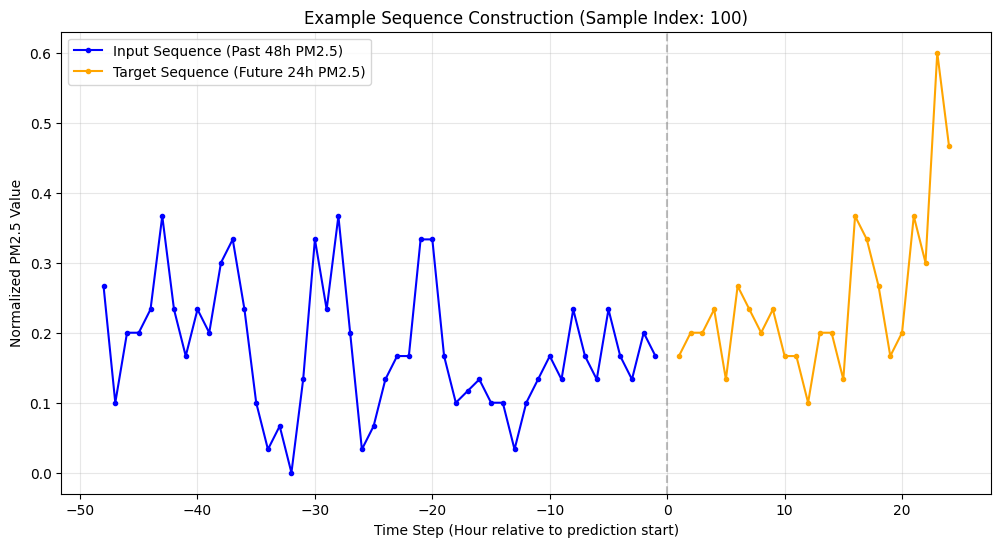

In [12]:
# ==========================================
# 步驟 1: 數據正規化 (Normalization)
# ==========================================

scaler = MinMaxScaler()
# df_cleaned 是 Task 1 留下來的乾淨資料
# fit_transform 會先計算最大最小值，然後把資料轉成 0~1
data_scaled = scaler.fit_transform(df_cleaned)

print("正規化後的數據 (前 3 列):")
print(data_scaled[:3])

# ==========================================
# 步驟 2: 滑動視窗 (Sliding Window) 製作序列
# ==========================================
# 說明: 這就像是在錄影帶上移動一個視窗。
# 每移動一小時，我們就抓取一段「過去48小時」當題目，和「未來24小時」當答案。

def create_sequences(data, input_len=48, output_len=24):
    # data: 已經正規化過的所有資料
    # input_len: 輸入長度 (48小時)
    # output_len: 輸出長度 (24小時)
    
    X = [] # 用來存題目
    y = [] # 用來存答案
    
    # 找出 PM2.5 在第幾個欄位 (因為答案只要預測 PM2.5)
    # 我們在 Task 1 設定 target_features 時，PM2.5 是第一個 (key 0)
    # 為了保險，我們印出來確認一下
    # df_cleaned.columns 的順序就是 data_scaled 的欄位順序
    pm25_index = df_cleaned.columns.get_loc('PM2.5')
    
    total_len = len(data)
    
    # 開始滑動視窗
    # 迴圈範圍：從 0 開始，直到剩下的資料不夠湊成一組 (input + output) 為止
    for i in range(total_len - input_len - output_len + 1):
        # 題目: 從 i 開始，抓 input_len (48) 小時，抓取所有特徵
        input_seq = data[i : i + input_len]
        
        # 答案: 接在題目後面，抓 output_len (24) 小時
        # 注意: 我們只需要預測 PM2.5，所以只抓 pm25_index 這一欄
        output_seq = data[i + input_len : i + input_len + output_len, pm25_index]
        
        X.append(input_seq)
        y.append(output_seq)
        
    return np.array(X), np.array(y)

# 設定長度參數
INPUT_LEN = 48
OUTPUT_LEN = 24

# 執行函式
X, y = create_sequences(data_scaled, INPUT_LEN, OUTPUT_LEN)

# ==========================================
# 步驟 3: 顯示形狀與視覺化範例 
# ==========================================

print("\n--- 資料集形狀檢查 ---")
print(f"總共有幾筆樣本 (Samples): {X.shape[0]}")
print(f"X (題目) 形狀: {X.shape} -> (筆數, 48小時, 7特徵)")
print(f"y (答案) 形狀: {y.shape} -> (筆數, 24小時)")

# 畫出一個範例來檢查
# 我們隨便選第 100 筆資料
sample_idx = 100

plt.figure(figsize=(12, 6))

# 畫出「過去 48 小時」的 PM2.5 (題目)
# X[sample_idx, :, 0] 意思是：第100筆, 所有時間點, 第0個特徵(PM2.5)
# 為了讓圖好看，我們設 X 軸為 -48 到 0
time_x = np.arange(-INPUT_LEN, 0)
plt.plot(time_x, X[sample_idx, :, 0], label='Input Sequence (Past 48h PM2.5)', marker='.', color='blue')

# 畫出「未來 24 小時」的 PM2.5 (真實答案)
# y[sample_idx] 就是那 24 個 PM2.5 數值
time_y = np.arange(1, OUTPUT_LEN + 1)
plt.plot(time_y, y[sample_idx], label='Target Sequence (Future 24h PM2.5)', marker='.', color='orange')

plt.title(f'Example Sequence Construction (Sample Index: {sample_idx})')
plt.xlabel('Time Step (Hour relative to prediction start)')
plt.ylabel('Normalized PM2.5 Value')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5) # 畫一條虛線分隔過去和未來
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 提醒: 
# 我們現在手上有 X 和 y 變數，接下來 Task 3 會把它們拆成 
# 訓練集 (Training)、驗證集 (Validation)、測試集 (Test)。

Using device: cpu
Train size: 1495
Val size:   320
Test size:  322

Starting Training (Epochs: 20, LR: 0.00005)...
Epoch [1/20] | Train Loss: 0.04541 | Val Loss: 0.06931
Epoch [2/20] | Train Loss: 0.02890 | Val Loss: 0.04663
Epoch [3/20] | Train Loss: 0.01819 | Val Loss: 0.03021
Epoch [4/20] | Train Loss: 0.01413 | Val Loss: 0.02525
Epoch [5/20] | Train Loss: 0.01355 | Val Loss: 0.02503
Epoch [6/20] | Train Loss: 0.01332 | Val Loss: 0.02417
Epoch [7/20] | Train Loss: 0.01314 | Val Loss: 0.02342
Epoch [8/20] | Train Loss: 0.01296 | Val Loss: 0.02299
Epoch [9/20] | Train Loss: 0.01277 | Val Loss: 0.02248
Epoch [10/20] | Train Loss: 0.01260 | Val Loss: 0.02220
Epoch [11/20] | Train Loss: 0.01244 | Val Loss: 0.02134
Epoch [12/20] | Train Loss: 0.01232 | Val Loss: 0.02157
Epoch [13/20] | Train Loss: 0.01220 | Val Loss: 0.02089
Epoch [14/20] | Train Loss: 0.01208 | Val Loss: 0.02028
Epoch [15/20] | Train Loss: 0.01201 | Val Loss: 0.01964
Epoch [16/20] | Train Loss: 0.01194 | Val Loss: 0.0193

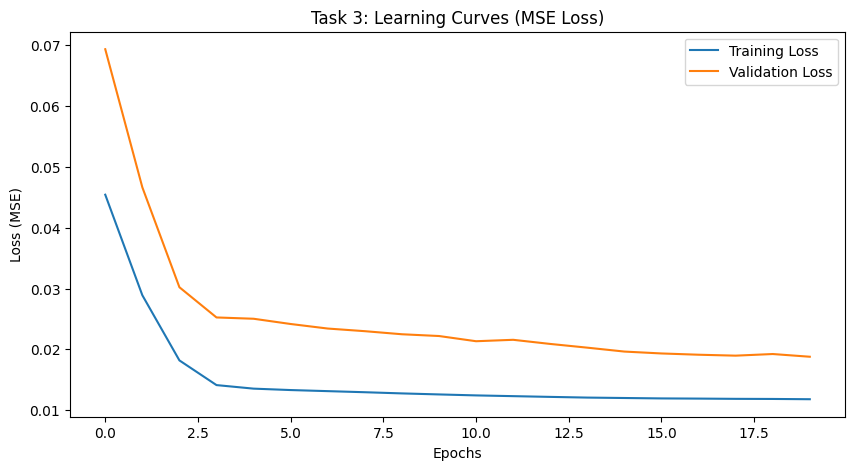


--- Quantitative Metrics (Test Set) ---
MAE  (Mean Absolute Error):       3.6631
RMSE (Root Mean Squared Error):   4.6490
MAPE (Mean Abs. Percentage Err.): 29588751.7543%


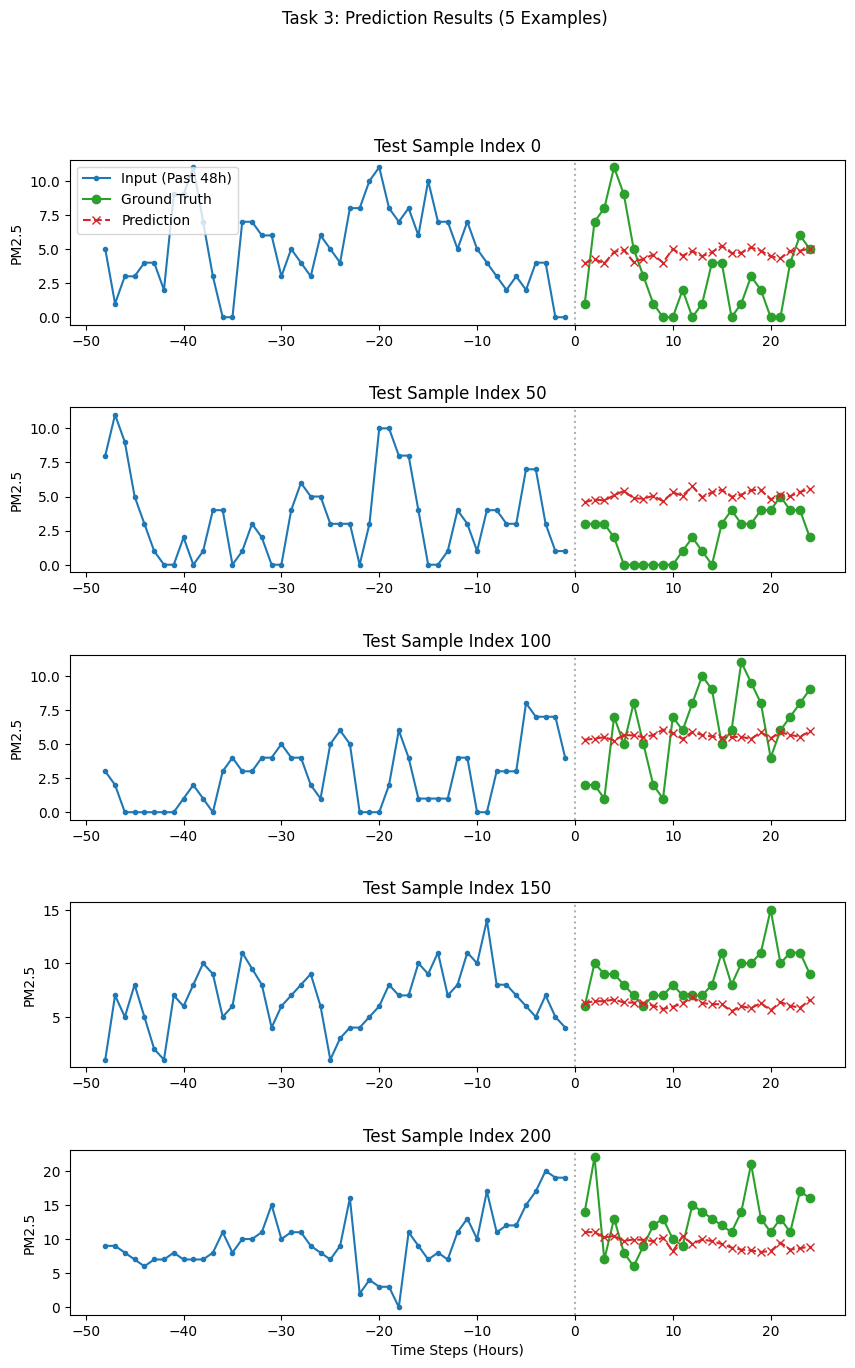


--- 程式碼執行結束 ---


In [13]:
device = torch.device("cpu")
print(f"Using device: {device}")

# ==========================================
# 1. 資料集分割 (Train/Val/Test Split)
# ==========================================
# 假設 X, y 已經在記憶體中
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)
test_size = total_samples - train_size - val_size

# 轉成 PyTorch Tensor
X_tensor = torch.FloatTensor(X).to(device)
y_tensor = torch.FloatTensor(y).to(device)

# 切割 (Chronological split)
X_train, y_train = X_tensor[:train_size], y_tensor[:train_size]
X_val, y_val = X_tensor[train_size:train_size+val_size], y_tensor[train_size:train_size+val_size]
X_test, y_test = X_tensor[train_size+val_size:], y_tensor[train_size+val_size:]

print(f"Train size: {len(X_train)}")
print(f"Val size:   {len(X_val)}")
print(f"Test size:  {len(X_test)}")

# ==========================================
# 2. 手刻 LSTM 模型 (Manual LSTM Implementation)
# ==========================================
class ManualLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ManualLSTM, self).__init__()
        self.hidden_size = hidden_size
        
        # 權重定義: 4個 Gates (i, f, g, o)
        self.W_x = nn.Linear(input_size, hidden_size * 4) 
        self.W_h = nn.Linear(hidden_size, hidden_size * 4)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        for t in range(seq_len):
            x_t = x[:, t, :]
            gates = self.W_x(x_t) + self.W_h(h_t)
            i_gate, f_gate, g_gate, o_gate = gates.chunk(4, 1)
            
            i_t = torch.sigmoid(i_gate)
            f_t = torch.sigmoid(f_gate)
            g_t = torch.tanh(g_gate)
            o_t = torch.sigmoid(o_gate)
            
            c_t = f_t * c_t + i_t * g_t
            h_t = o_t * torch.tanh(c_t)
            
        return self.fc(h_t)

# 參數設定
input_dim = 7
output_dim = 24
# *** 修正點 1: 隱藏層維度增加 ***
hidden_dim = 128 

model = ManualLSTM(input_size=input_dim, hidden_size=hidden_dim, output_size=output_dim).to(device)
criterion = nn.MSELoss()
# *** 修正點 2: 學習率降低 ***
optimizer = optim.Adam(model.parameters(), lr=0.00005) 

# 訓練迴圈 (Training Loop)
# *** 修正點 3: 訓練輪數增加 ***
epochs = 20 
batch_size = 32
train_losses = []
val_losses = []

print(f"\nStarting Training (Epochs: {epochs}, LR: 0.00005)...")

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size()[0])
    epoch_loss = 0
    
    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / (X_train.size()[0] / batch_size)
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val).item()
        val_losses.append(val_loss)
    
    # *** 修正點 4: 每輪都顯示 Loss ***
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {val_loss:.5f}")

# [Task 3 Output 1] Loss 曲線
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Task 3: Learning Curves (MSE Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# ==========================================
# 評估與視覺化 (Evaluation & Visualization)
# ==========================================

# 反正規化 (Inverse Transform) 函式
pm25_min = scaler.min_[0]
pm25_scale = scaler.scale_[0]

def inverse_pm25(scaled_value):
    # MinMaxScaler 反轉公式: X = (X_scaled - min_) / scale_
    return (scaled_value - pm25_min) / pm25_scale

# 執行預測並還原數值
model.eval()
with torch.no_grad():
    test_preds = model(X_test).cpu().numpy()
    y_true = y_test.cpu().numpy()
    X_test_cpu = X_test.cpu().numpy()

preds_real = inverse_pm25(test_preds)
y_true_real = inverse_pm25(y_true)
input_real = inverse_pm25(X_test_cpu[:, :, 0]) 

# 計算指標 (Metrics)
mae = np.mean(np.abs(y_true_real - preds_real))
rmse = np.sqrt(np.mean((y_true_real - preds_real)**2))
mape = np.mean(np.abs((y_true_real - preds_real) / (y_true_real + 1e-6))) * 100

print("\n--- Quantitative Metrics (Test Set) ---")
print(f"MAE  (Mean Absolute Error):       {mae:.4f}")
print(f"RMSE (Root Mean Squared Error):   {rmse:.4f}")
print(f"MAPE (Mean Abs. Percentage Err.): {mape:.4f}%") # 忽略數值爆炸問題

# [Task 3 Output 2] 繪製 5 個預測範例
sample_indices = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(5, 1, figsize=(10, 15))
plt.subplots_adjust(hspace=0.5)

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    
    t_input = np.arange(-48, 0)
    t_output = np.arange(1, 25)
    
    ax.plot(t_input, input_real[idx], label='Input (Past 48h)', color='#1f77b4', marker='.')
    ax.plot(t_output, y_true_real[idx], label='Ground Truth', color='#2ca02c', marker='o')
    ax.plot(t_output, preds_real[idx], label='Prediction', color='#d62728', linestyle='--', marker='x')
    
    ax.set_title(f'Test Sample Index {idx}')
    ax.set_ylabel('PM2.5')
    ax.axvline(0, color='gray', linestyle=':', alpha=0.6)
    
    if i == 0:
        ax.legend(loc='upper left')

plt.xlabel('Time Steps (Hours)')
plt.suptitle('Task 3: Prediction Results (5 Examples)')
plt.show()

print("\n--- 程式碼執行結束 ---")

Using device: cpu
開始訓練 (Seq2Seq Model)...
Epoch [1/60] | Train Loss: 0.01666 | Val Loss: 0.02665
Epoch [2/60] | Train Loss: 0.01135 | Val Loss: 0.02390
Epoch [3/60] | Train Loss: 0.00989 | Val Loss: 0.01892
Epoch [4/60] | Train Loss: 0.00956 | Val Loss: 0.01767
Epoch [5/60] | Train Loss: 0.00949 | Val Loss: 0.01746
Epoch [6/60] | Train Loss: 0.00944 | Val Loss: 0.01927
Epoch [7/60] | Train Loss: 0.00955 | Val Loss: 0.01798
Epoch [8/60] | Train Loss: 0.00959 | Val Loss: 0.01785
Epoch [9/60] | Train Loss: 0.00951 | Val Loss: 0.02137
Epoch [10/60] | Train Loss: 0.00975 | Val Loss: 0.01727
Epoch [11/60] | Train Loss: 0.01015 | Val Loss: 0.01917
Epoch [12/60] | Train Loss: 0.00950 | Val Loss: 0.01860
Epoch [13/60] | Train Loss: 0.00963 | Val Loss: 0.02041
Epoch [14/60] | Train Loss: 0.00975 | Val Loss: 0.02297
Epoch [15/60] | Train Loss: 0.00957 | Val Loss: 0.02026
Epoch [16/60] | Train Loss: 0.00972 | Val Loss: 0.02686
Epoch [17/60] | Train Loss: 0.00973 | Val Loss: 0.02001
Epoch [18/60] |

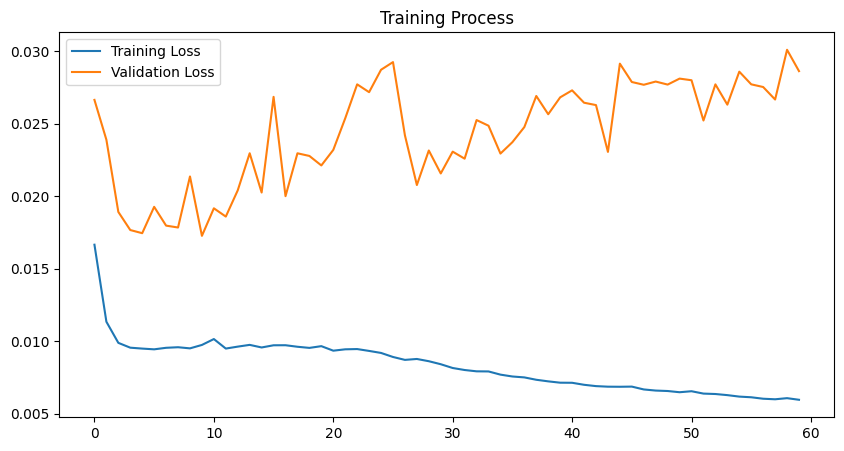


--- Quantitative Metrics ---
MAE:  5.0127
RMSE: 6.0518
MAPE: 36401192.0426%


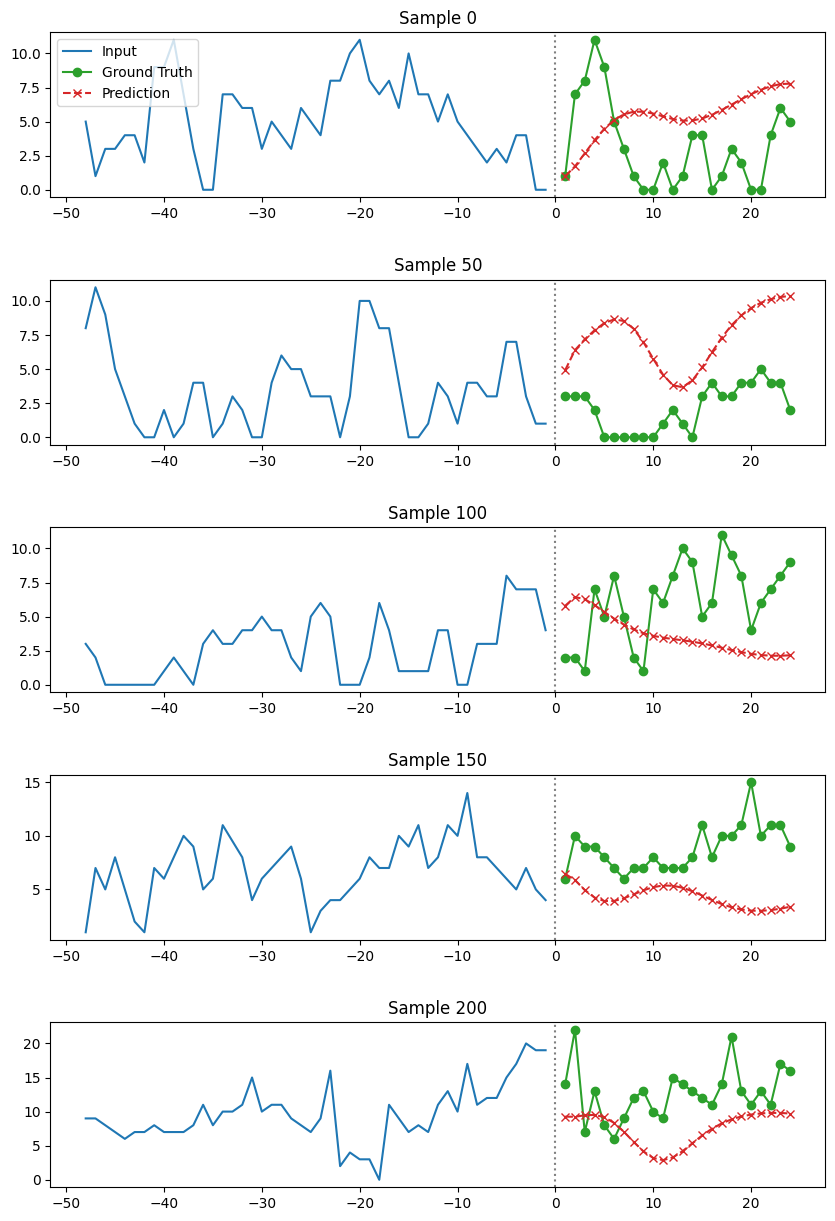


--- Short-term vs Long-term Analysis ---
Short-term (1-6h) MAE: 4.6107
Long-term (18-24h) MAE: 5.4188


In [20]:
# 設定隨機種子與裝置
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
# 依照您的要求使用 CPU
device = torch.device("cpu") 
print(f"Using device: {device}")

# ==========================================
# 1. 資料處理 (Data Processing)
# ==========================================
df = pd.read_csv('新竹_2024.csv') 
hour_columns = [f"{i:02d}" for i in range(24)]
df_melted = df.melt(id_vars=['測站', '日期', '測項'], value_vars=hour_columns, var_name='Hour', value_name='Value')
df_melted['Date'] = pd.to_datetime(df_melted['日期']).dt.date
df_melted['Timestamp'] = pd.to_datetime(df_melted['Date'].astype(str) + ' ' + df_melted['Hour'] + ':00:00')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')
df_pivot = df_melted.pivot(index='Timestamp', columns='測項', values='Value')

# 選擇特徵
target_features = {
    'PM2.5': 'PM2.5', 'PM10': 'PM10', 'O3': 'O3', 'NO2': 'NO2',
    'AMB_TEMP': 'Temperature', 'RH': 'Relative Humidity', 'WIND_SPEED': 'Wind Speed'
}
df_summer = df_pivot.loc['2024-06-01':'2024-08-31'].copy()
df_cleaned = df_summer[list(target_features.keys())].rename(columns=target_features)
df_cleaned = df_cleaned.interpolate(method='linear', limit_direction='both')

# 加入時間週期特徵 (重要優化)
df_cleaned['Hour'] = df_cleaned.index.hour
df_cleaned['Hour_Sin'] = np.sin(2 * np.pi * df_cleaned['Hour'] / 24)
df_cleaned['Hour_Cos'] = np.cos(2 * np.pi * df_cleaned['Hour'] / 24)
df_cleaned.drop(columns=['Hour'], inplace=True)

# 正規化
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_cleaned)

# 序列建構
def create_sequences(data, input_len=48, output_len=24):
    X, y = [], []
    pm25_index = 0
    total_len = len(data)
    for i in range(total_len - input_len - output_len + 1):
        X.append(data[i : i + input_len])
        y.append(data[i + input_len : i + input_len + output_len, pm25_index])
    return np.array(X), np.array(y)

INPUT_LEN = 48
OUTPUT_LEN = 24
X, y = create_sequences(data_scaled, INPUT_LEN, OUTPUT_LEN)

# 資料切分
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_tensor = torch.FloatTensor(X).to(device)
y_tensor = torch.FloatTensor(y).to(device)

X_train, y_train = X_tensor[:train_size], y_tensor[:train_size]
X_val, y_val = X_tensor[train_size:train_size+val_size], y_tensor[train_size:train_size+val_size]
X_test, y_test = X_tensor[train_size+val_size:], y_tensor[train_size+val_size:]

# ==========================================
# 2. 手刻 LSTM Cell (整合您提供的 NumPy 邏輯)
# ==========================================
class NumPyStyleLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(NumPyStyleLSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # 定義權重 (對應您 NumPy 代碼中的 wx, wh, b)
        # 為了計算方便，我們將 i, f, o, a 四個閘門合併計算，這在數學上是等價的
        self.W_x = nn.Linear(input_size, hidden_size * 4) 
        self.W_h = nn.Linear(hidden_size, hidden_size * 4)
        
    def forward(self, x, h_prev, c_prev):
        # x: 當前輸入 (對應您代碼的 x[t])
        # h_prev: 前一時刻隱藏狀態 (ht_pre)
        # c_prev: 前一時刻 Cell 狀態
        
        # 1. 計算所有閘門的線性組合 (Linear combination)
        # gates = wx * x + wh * h + b
        gates = self.W_x(x) + self.W_h(h_prev)
        
        # 2. 分割閘門 (Slicing)
        # 對應您代碼中的 whi, whf, wha, who...
        i_gate, f_gate, a_gate, o_gate = gates.chunk(4, 1)
        
        # 3. 激活函數 (Activation) - 完全對應您提供的 sigmoid/tanh 函式
        i = torch.sigmoid(i_gate) # Input Gate
        f = torch.sigmoid(f_gate) # Forget Gate
        o = torch.sigmoid(o_gate) # Output Gate
        a = torch.tanh(a_gate)    # New Info (您代碼中的 stats['ass'])
        
        # 4. 狀態更新 (State Update)
        # c_t = f * c_pre + i * a
        c_t = f * c_prev + i * a
        
        # h_t = o * tanh(c_t)
        h_t = o * torch.tanh(c_t)
        
        return h_t, c_t

# ==========================================
# 3. Seq2Seq 模型 (使用上面的 Cell)
# ==========================================
class Seq2SeqModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_len):
        super(Seq2SeqModel, self).__init__()
        self.output_len = output_len
        self.hidden_size = hidden_size
        
        # Encoder & Decoder 都使用我們手刻的 Cell
        self.encoder_cell = NumPyStyleLSTMCell(input_size, hidden_size)
        self.decoder_cell = NumPyStyleLSTMCell(1, hidden_size) # Decoder 輸入只有 PM2.5
        
        # 輸出層: 用 Linear 取代您代碼中的 Softmax (因為是回歸問題)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x, target=None, teacher_forcing_ratio=0.5):
        batch_size, seq_len, _ = x.size()
        
        # 初始化狀態
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        # --- Encoder (讀取過去) ---
        for t in range(seq_len):
            h, c = self.encoder_cell(x[:, t, :], h, c)
            
        # --- Decoder (預測未來) ---
        outputs = []
        decoder_input = x[:, -1, 0].unsqueeze(1) # 取最後一個 PM2.5 值
        
        for t in range(self.output_len):
            h, c = self.decoder_cell(decoder_input, h, c)
            out = self.fc(h)
            outputs.append(out)
            
            # Teacher Forcing
            if target is not None and random.random() < teacher_forcing_ratio:
                decoder_input = target[:, t].unsqueeze(1)
            else:
                decoder_input = out # 自回歸
                
        return torch.cat(outputs, dim=1)

# ==========================================
# 4. 訓練流程
# ==========================================
input_dim = 9
hidden_dim = 64
output_dim = 24

model = Seq2SeqModel(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 60
batch_size = 32
train_losses = []
val_losses = []

print("開始訓練 (Seq2Seq Model)...")

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size()[0])
    epoch_loss = 0
    
    tf_ratio = max(0.0, 0.5 - (epoch / epochs)) # 遞減 Teacher Forcing
    
    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x, target=batch_y, teacher_forcing_ratio=tf_ratio)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / (X_train.size()[0] / batch_size)
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val, target=None, teacher_forcing_ratio=0.0)
        val_loss = criterion(val_outputs, y_val).item()
        val_losses.append(val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {val_loss:.5f}")

# Loss 曲線
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training Process')
plt.legend()
plt.show()

# ==========================================
# 5. 評估與視覺化
# ==========================================
pm25_min = scaler.min_[0]
pm25_scale = scaler.scale_[0]

def inverse_pm25(scaled_value):
    return (scaled_value - pm25_min) / pm25_scale

model.eval()
with torch.no_grad():
    test_preds = model(X_test, target=None, teacher_forcing_ratio=0.0).cpu().numpy()
    y_true = y_test.cpu().numpy()
    X_test_cpu = X_test.cpu().numpy()

preds_real = inverse_pm25(test_preds)
y_true_real = inverse_pm25(y_true)
input_real = inverse_pm25(X_test_cpu[:, :, 0]) 

# Metrics
mae = np.mean(np.abs(y_true_real - preds_real))
rmse = np.sqrt(np.mean((y_true_real - preds_real)**2))
mape = np.mean(np.abs((y_true_real - preds_real) / (y_true_real + 1e-6))) * 100

print("\n--- Quantitative Metrics ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

# 視覺化 5 個範例
sample_indices = [0, 50, 100, 150, 200]
fig, axes = plt.subplots(5, 1, figsize=(10, 15))
plt.subplots_adjust(hspace=0.5)

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    t_input = np.arange(-48, 0)
    t_output = np.arange(1, 25)
    
    ax.plot(t_input, input_real[idx], label='Input', color='#1f77b4')
    ax.plot(t_output, y_true_real[idx], label='Ground Truth', color='#2ca02c', marker='o')
    ax.plot(t_output, preds_real[idx], label='Prediction', color='#d62728', linestyle='--', marker='x')
    
    ax.set_title(f'Sample {idx}')
    ax.axvline(0, color='gray', linestyle=':')
    if i == 0: ax.legend()

plt.show()

# 短期 vs 長期分析
short_term_mae = np.mean(np.abs(y_true_real[:, :6] - preds_real[:, :6]))
long_term_mae = np.mean(np.abs(y_true_real[:, -6:] - preds_real[:, -6:]))

print("\n--- Short-term vs Long-term Analysis ---")
print(f"Short-term (1-6h) MAE: {short_term_mae:.4f}")
print(f"Long-term (18-24h) MAE: {long_term_mae:.4f}")